# Time-resolved Fano-factor PSTHs, split by trial condition
For each time bin (sliding window), the per-neuron Fano factor (var/mean of windowed spike counts across trials) averaged over neurons. Shown for an example session split by contrast / side / choice / outcome / block, then averaged across sessions with region selection. Controls: causal window, equal trials per level, optional common neuron count.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [8]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

REGION_LEVEL = 'beryl'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
WIN_BINS = 6               # ~100 ms sliding window (matches ff computation script)
SMOOTH_MODE = 'causal'     # 'causal' (only bins <= t) or 'centered'
MIN_NEURONS = 15
MIN_LEVEL_TRIALS = 15
BALANCE_LEVELS = True      # subsample to a SINGLE global trial count shared across ALL split vars
N_SUBSAMPLE_REPEATS = 10   # average the FF over this many random subsamples (reduces draw variance)
REMOVE_CONDITION = False    # subtract stimulus (side x contrast) means before variance
                           # -> condition-adjusted 'noise' Fano factor (matches ff computation script)
N_NEURONS_CAP = None       # if int, subsample each region to this many neurons
MIN_MEAN_COUNT = 0.1       # exclude neuron-timepoints with mean count <= this
SPLIT_VARS = ['contrast', 'side', 'choice', 'feedback', 'block']
SPLIT_VARS = ['contrast', 'feedback']
SEED = 0

trials_df = pd.read_parquet(trials_path)
trial_beh = {s: g.set_index('trial_id')[['choice', 'correct', 'block']] for s, g in trials_df.groupby('session')}
br = BrainRegions()
print("params set")

params set


## Compute Fano-factor PSTHs per session x region x condition level

In [9]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))

def smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def ff_curve(A, cond=None):
    """A: neurons x trials x T (windowed spike counts). Mean Fano factor across neurons per bin.
    If REMOVE_CONDITION and cond given, variance is computed on residuals after subtracting each
    stimulus-condition mean (condition-adjusted / mean-matched FF)."""
    mean = np.nanmean(A, axis=1)                     # neurons x T (overall mean)
    if REMOVE_CONDITION and cond is not None:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]
            resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_MEAN_COUNT) | ~np.isfinite(ff)] = np.nan
    return np.nanmean(ff, axis=0)

rng = np.random.default_rng(SEED)
records = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        beh = trial_beh.get(session)
        if beh is None: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values

        cond = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials)
        meta = pd.DataFrame(index=trials)
        meta['side'] = cond.str.split('_').str[0].values
        meta['contrast'] = cond.str.split('_').str[1].astype(float).values
        meta['choice'] = beh['choice'].reindex(trials).values
        meta['feedback'] = beh['correct'].reindex(trials).map({1.0: 'correct', 0.0: 'incorrect'}).values
        meta['block'] = beh['block'].reindex(trials).values
        meta['stim_cond'] = cond.values                    # side x contrast

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            if N_NEURONS_CAP and len(ni) > N_NEURONS_CAP:
                ni = rng.choice(ni, N_NEURONS_CAP, replace=False)
            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))
            if complete.sum() < MIN_LEVEL_TRIALS: continue
            Aw = smooth_time(Asub[:, complete, :], WIN_BINS, SMOOTH_MODE) * WIN_BINS   # windowed counts
            cmeta = meta.iloc[np.where(complete)[0]]
            conds = cmeta['stim_cond'].values

            # valid levels per split var, and a SINGLE global trial count across all vars
            var_levels, all_counts = {}, []
            for var in SPLIT_VARS:
                vals = cmeta[var]
                lv = [x for x in vals.dropna().unique() if (vals == x).sum() >= MIN_LEVEL_TRIALS]
                if len(lv) >= 2:
                    var_levels[var] = lv
                    all_counts += [int((vals == x).sum()) for x in lv]
            if not var_levels: continue
            n_global = min(all_counts) if BALANCE_LEVELS else None

            for var, levels in var_levels.items():
                vals = cmeta[var].values
                for level in levels:
                    idx_all = np.where(vals == level)[0]
                    if BALANCE_LEVELS:
                        reps = []
                        for _ in range(N_SUBSAMPLE_REPEATS):
                            sub = rng.choice(idx_all, n_global, replace=False)
                            reps.append(ff_curve(Aw[:, sub, :], conds[sub]))
                        curve = np.nanmean(reps, axis=0); n_used = n_global
                    else:
                        curve = ff_curve(Aw[:, idx_all, :], conds[idx_all]); n_used = len(idx_all)
                    records.append(dict(session=session, region=region, var=var, level=level,
                                        n_neurons=len(ni), n_trials=int(n_used), curve=curve))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Computed {len(curves)} curves | {curves['session'].nunique()} sessions | "
      f"global n per session-region used (median trials/level = {curves['n_trials'].median():.0f})")

  100/380 files...
  200/380 files...
  300/380 files...
Computed 5281 curves | 222 sessions | global n per session-region used (median trials/level = 21)


## Plot helpers

In [10]:
def _order_levels(var, levels):
    if var in ('contrast', 'block'):
        return sorted(levels, key=lambda x: float(x))
    return sorted(levels, key=str)

def _agg(df_sub):
    out = {}
    for level, g in df_sub.groupby('level'):
        per_sess = g.groupby('session')['curve'].apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0))
        out[level] = np.vstack(per_sess.values)
    return out

def plot_grid(df, session=None, regions=None, title='', xlim=(-0.3, 0.6)):
    d = df.copy()
    if session is not None: d = d[d['session'] == session]
    if regions is not None: d = d[d['region'].isin(regions)]
    vars_present = [v for v in SPLIT_VARS if v in d['var'].unique()]
    fig, axes = plt.subplots(1, len(vars_present), figsize=(4.2 * len(vars_present), 4.2), squeeze=False)
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1])
    for k, var in enumerate(vars_present):
        ax = axes[0][k]
        agg = _agg(d[d['var'] == var])
        levels = _order_levels(var, list(agg.keys()))
        cmap = plt.cm.viridis(np.linspace(0, 1, len(levels))) if var in ('contrast', 'block') \
               else plt.cm.tab10(np.linspace(0, 1, len(levels)))
        yvals = []
        for c, level in zip(cmap, levels):
            M = agg[level]; mean = np.nanmean(M, axis=0)
            ax.plot(tsec, mean, color=c, lw=2, label=f'{level} (N={M.shape[0]})')
            if M.shape[0] > 1:
                sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
                ax.fill_between(tsec, mean - sem, mean + sem, color=c, alpha=0.15)
                yvals += [(mean - sem)[xmask], (mean + sem)[xmask]]
            else:
                yvals += [mean[xmask]]
        ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mean Fano factor'); ax.set_title(var, fontsize=11)
        ax.set_xlim(list(xlim))
        # autoscale y to the data in the visible window
        if yvals:
            allv = np.concatenate(yvals); lo, hi = np.nanmin(allv), np.nanmax(allv)
            pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
            ax.set_ylim(lo - pad, hi + pad)
            if lo - pad <= 1.0 <= hi + pad:            # FF=1 reference only if in range
                ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
        ax.legend(fontsize=7); sns.despine(ax=ax, offset=4)
    fig.suptitle(title, y=1.03, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Example session

Example session: d33baf74-263c-4b37-a0d0-b79dcb80a764  (regions: ['AON', 'DG', 'DP', 'LD', 'MOs', 'ORBm', 'ORBvl', 'PL', 'PO', 'VPM'])


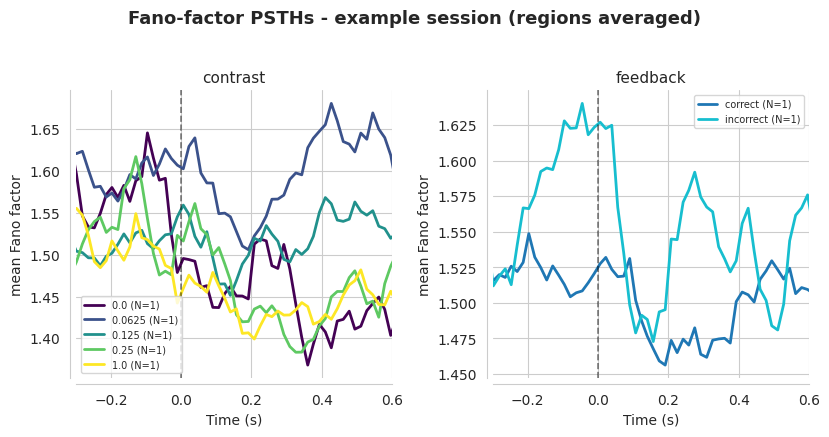

In [11]:
ex = curves.groupby('session')['n_neurons'].sum().idxmax()
print(f"Example session: {ex}  (regions: {sorted(curves[curves.session==ex]['region'].unique())})")
plot_grid(curves, session=ex, title='Fano-factor PSTHs - example session (regions averaged)')

## Averaged across sessions (select regions or all)

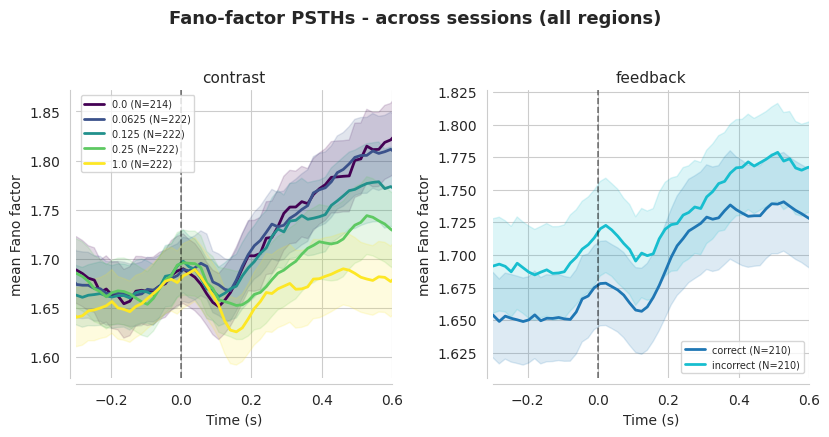

In [12]:
REGIONS = None   # None -> average across all regions; or a list e.g. ['Isocortex']
plot_grid(curves, regions=REGIONS,
          title=f'Fano-factor PSTHs - across sessions ({"all regions" if REGIONS is None else REGIONS})')

In [7]:
plot_grid(curves, regions=['Isocortex'],
          title='Fano-factor PSTHs - across sessions (Isocortex)')

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x420 with 0 Axes>